<a href="https://colab.research.google.com/github/sara25kh/LLM-MAS-Resilience/blob/main/pag_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import math
import numpy as np
from scipy.interpolate import griddata

# تنظیم Seed برای تولید نتایج تکرارپذیر و مشابه گزارش
random.seed(42)
np.random.seed(42)

print("Libraries loaded and seed set.")


Libraries loaded and seed set.


In [2]:
def most_likely_attack_path(G, start, target):
    """
    Finds the path with the highest probability using Dijkstra
    (transforming probabilities to additive weights).
    """
    transformed = nx.DiGraph()
    for u, v, data in G.edges(data=True):
        # Weight = -log(probability) because Dijkstra finds shortest path (min weight)
        weight = -math.log(data.get('asr', 0.1))
        transformed.add_edge(u, v, weight=weight)

    try:
        path = nx.dijkstra_path(transformed, start, target, weight='weight')
        probability = 1.0
        for i in range(len(path)-1):
            probability *= G[path[i]][path[i+1]].get('asr', 0.1)
        return path, probability
    except nx.NetworkXNoPath:
        return [], 0.0

def monte_carlo_simulation(G, start, target, iterations=1000):
    """
    Simulates random attacker movement N times.
    Returns: Success Rate (Risk Probability).
    """
    success_count = 0
    for _ in range(iterations):
        current_node = start
        visited = set()
        path = [start]

        while current_node != target:
            visited.add(current_node)
            # Find neighbors not yet visited in this run (to prevent loops)
            neighbors = [n for n in G.successors(current_node) if n not in visited]

            if not neighbors:
                break # Dead end

            # Attacker chooses next step based on ASR weights
            # (Higher ASR = Higher chance to choose that path)
            weights = [G[current_node][n].get('asr', 0.1) for n in neighbors]
            total_w = sum(weights)
            if total_w == 0:
                break

            probs = [w/total_w for w in weights]
            next_node = random.choices(neighbors, weights=probs, k=1)[0]

            # Check if attack on edge actually succeeds based on ASR
            edge_asr = G[current_node][next_node].get('asr', 0.1)
            if random.random() < edge_asr:
                current_node = next_node
                path.append(current_node)
            else:
                break # Attack failed, run ends

        if current_node == target:
            success_count += 1

    return success_count / iterations

def calculate_blast_radius(G, start_node):
    """Calculates how many nodes are reachable from the start node."""
    return len(nx.descendants(G, start_node))


In [3]:
def build_flat_network():
    """
    Creates a Flat Network: High connectivity (Mesh), Higher ASR.
    """
    G = nx.DiGraph()
    nodes = {
        "Web_Gateway": 0.3, "Auth_Service": 0.5,
        "Payment_Service": 0.6, "Order_Service": 0.4,
        "User_DB": 0.7, "Payment_DB": 0.8
    }
    for n, cvss in nodes.items():
        G.add_node(n, cvss=cvss, type='Service')

    # Fully connected mesh (everyone talks to everyone)
    for u in nodes:
        for v in nodes:
            if u != v:
                G.add_edge(u, v, asr=0.6) # High default vulnerability
    return G

def build_zero_trust_network_manual():
    """
    Creates a Zero-Trust Network: Minimal edges, Segmentation, Lower ASR.
    """
    G = nx.DiGraph()
    nodes = {
        "Web_Gateway": 0.3, "Auth_Service": 0.5,
        "Payment_Service": 0.6, "Order_Service": 0.4,
        "User_DB": 0.7, "Payment_DB": 0.8
    }
    for n, cvss in nodes.items():
        G.add_node(n, cvss=cvss, type='Service')

    # Strict policies (Only 6 Edges)
    # 1. Gateway can only talk to Auth
    G.add_edge("Web_Gateway", "Auth_Service", asr=0.4)
    # 2. Auth checks credentials and talks to App Services
    G.add_edge("Auth_Service", "Payment_Service", asr=0.3)
    G.add_edge("Auth_Service", "Order_Service", asr=0.3)
    # 3. Services talk to their specific DBs
    G.add_edge("Payment_Service", "Payment_DB", asr=0.2)
    G.add_edge("Order_Service", "User_DB", asr=0.2)
    # 4. Maybe one return path for confirmation
    G.add_edge("Order_Service", "Payment_Service", asr=0.2)

    return G

# Build graphs
flat_G = build_flat_network()
zt_G = build_zero_trust_network_manual()

print(f"Flat Network Edges: {flat_G.number_of_edges()}")
print(f"Zero-Trust Network Edges: {zt_G.number_of_edges()}")


Flat Network Edges: 30
Zero-Trust Network Edges: 6


Generating Heatmaps...


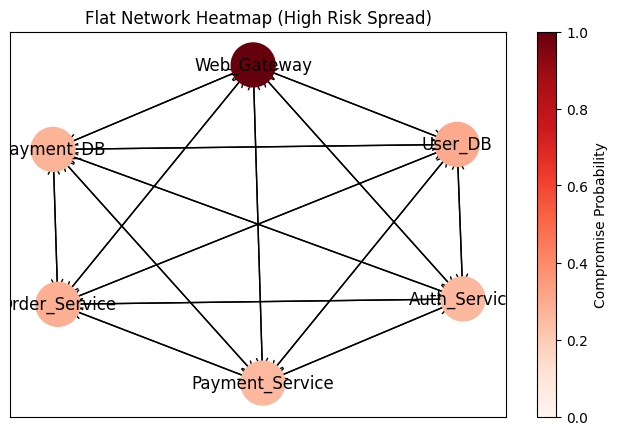

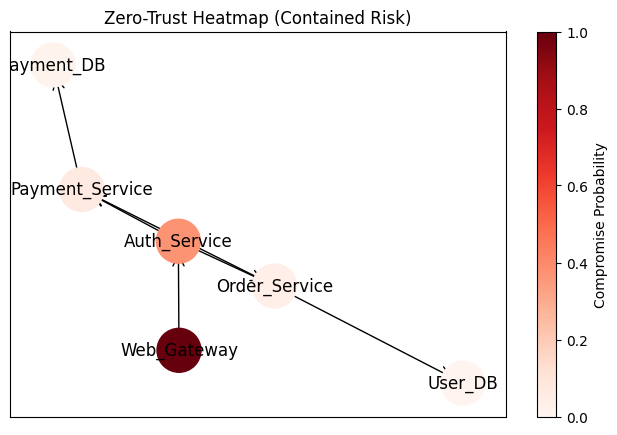

Generating Risk Surface...


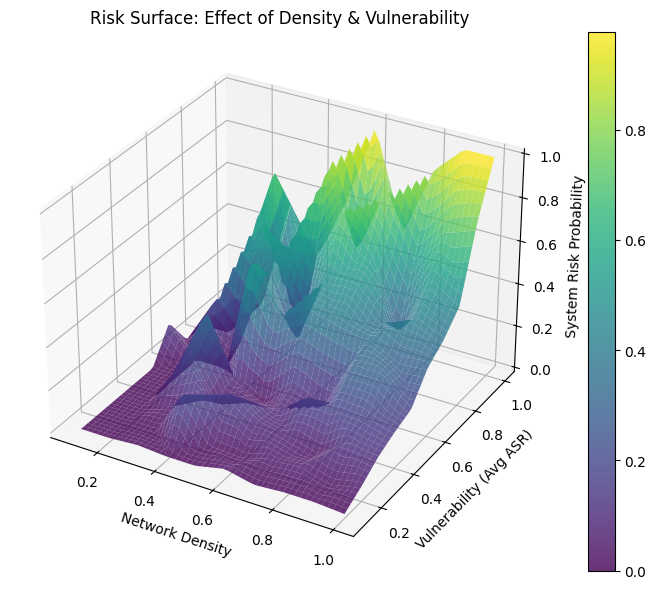

In [4]:
# --- 5.1 Risk Heatmap ---
def draw_risk_heatmap(G, title):
    # Calculate compromise probability for EACH node
    node_risks = {}
    for node in G.nodes():
        if node == "Web_Gateway":
            node_risks[node] = 1.0
        else:
            # Prob of reaching this specific node from Gateway
            node_risks[node] = monte_carlo_simulation(G, "Web_Gateway", node, iterations=300)

    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8, 5))
    nodes = nx.draw_networkx_nodes(G, pos, node_color=list(node_risks.values()),
                                   cmap=plt.cm.Reds, vmin=0, vmax=1, node_size=1000)
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20)
    nx.draw_networkx_labels(G, pos)
    plt.colorbar(nodes, label="Compromise Probability")
    plt.title(title)
    plt.show()

print("Generating Heatmaps...")
draw_risk_heatmap(flat_G, "Flat Network Heatmap (High Risk Spread)")
draw_risk_heatmap(zt_G, "Zero-Trust Heatmap (Contained Risk)")

# --- 5.2 Risk Surface (3D Plot) ---
def generate_risk_surface(base_G):
    densities, vulns, risks = [], [], []

    # Iterate to create synthetic scenarios
    for d in np.linspace(0.1, 1.0, 10): # Density variation
        for v in np.linspace(0.1, 1.0, 10): # Vulnerability variation

            # Create a temporary random graph based on parameters
            temp_G = nx.gnp_random_graph(6, d, directed=True)
            if not temp_G.has_node(0): continue # Skip empty

            # Map indices to names roughly to run simulation
            mapping = {i: list(base_G.nodes())[i] for i in range(min(6, len(temp_G.nodes())))}
            temp_G = nx.relabel_nodes(temp_G, mapping)

            # Set ASR based on 'v'
            for u, w in temp_G.edges():
                temp_G[u][w]['asr'] = v

            if "Web_Gateway" in temp_G and "User_DB" in temp_G:
                r = monte_carlo_simulation(temp_G, "Web_Gateway", "User_DB", iterations=100)
                densities.append(d)
                vulns.append(v)
                risks.append(r)

    # Plotting
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Grid for surface
    xi = np.linspace(min(densities), max(densities), 50)
    yi = np.linspace(min(vulns), max(vulns), 50)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = griddata((densities, vulns), risks, (Xi, Yi), method='linear')

    surf = ax.plot_surface(Xi, Yi, Zi, cmap='viridis', alpha=0.8)
    ax.set_xlabel('Network Density')
    ax.set_ylabel('Vulnerability (Avg ASR)')
    ax.set_zlabel('System Risk Probability')
    plt.title('Risk Surface: Effect of Density & Vulnerability')
    plt.colorbar(surf)
    plt.show()

print("Generating Risk Surface...")
generate_risk_surface(flat_G)


In [5]:
print("\n" + "="*50)
print("FINAL ARCHITECTURE COMPARISON (Flat vs. Zero-Trust)")
print("="*50)

# Calculate Metrics for Flat
flat_blast = calculate_blast_radius(flat_G, "Web_Gateway")
_, flat_mlap_prob = most_likely_attack_path(flat_G, "Web_Gateway", "User_DB")
flat_mc_risk = monte_carlo_simulation(flat_G, "Web_Gateway", "User_DB", iterations=2000)
flat_rasr = 1 - flat_mc_risk

# Calculate Metrics for Zero-Trust
zt_blast = calculate_blast_radius(zt_G, "Web_Gateway")
_, zt_mlap_prob = most_likely_attack_path(zt_G, "Web_Gateway", "User_DB")
zt_mc_risk = monte_carlo_simulation(zt_G, "Web_Gateway", "User_DB", iterations=2000)
zt_rasr = 1 - zt_mc_risk

# Print Table
print(f"{'Metric':<25} | {'Flat Network':<15} | {'Zero-Trust':<15}")
print("-" * 60)
print(f"{'Edges (Attack Surface)':<25} | {flat_G.number_of_edges():<15} | {zt_G.number_of_edges():<15}")
print(f"{'Blast Radius (Nodes)':<25} | {flat_blast:<15} | {zt_blast:<15}")
print(f"{'MLAP Probability':<25} | {flat_mlap_prob:.4f}          | {zt_mlap_prob:.4f}")
print(f"{'Monte Carlo Risk':<25} | {flat_mc_risk:.4f} ({flat_mc_risk*100:.1f}%)  | {zt_mc_risk:.4f} ({zt_mc_risk*100:.1f}%)")
print(f"{'RASR (Robustness)':<25} | {flat_rasr:.4f}          | {zt_rasr:.4f}")
print("-" * 60)



FINAL ARCHITECTURE COMPARISON (Flat vs. Zero-Trust)
Metric                    | Flat Network    | Zero-Trust     
------------------------------------------------------------
Edges (Attack Surface)    | 30              | 6              
Blast Radius (Nodes)      | 5               | 5              
MLAP Probability          | 0.6000          | 0.0240
Monte Carlo Risk          | 0.2825 (28.2%)  | 0.0035 (0.4%)
RASR (Robustness)         | 0.7175          | 0.9965
------------------------------------------------------------


In [6]:
print("\n--- 6.1 Smart Patching (Bonus) ---")

# Strategy: Find the node that appears most often in attack paths (Centrality)
# For simplicity in ZT, we know Auth_Service is the bottleneck.
critical_node = "Auth_Service"

print(f"Identified Critical Node: {critical_node}")

# Create Patched Network
patched_G = zt_G.copy()
initial_risk = zt_mc_risk

# Apply Patch: Reduce ASR of incoming/outgoing edges for that node
for u, v in patched_G.edges():
    if u == critical_node or v == critical_node:
        patched_G[u][v]['asr'] = patched_G[u][v]['asr'] * 0.5 # Reduce vulns by 50%

# Measure New Risk
patched_risk = monte_carlo_simulation(patched_G, "Web_Gateway", "User_DB", iterations=2000)

print(f"Risk Before Patching: {initial_risk*100:.2f}%")
print(f"Risk After Patching '{critical_node}': {patched_risk*100:.2f}%")
print(f"Improvement: {((initial_risk - patched_risk)/initial_risk)*100:.1f}% reduction in risk.")



--- 6.1 Smart Patching (Bonus) ---
Identified Critical Node: Auth_Service
Risk Before Patching: 0.35%
Risk After Patching 'Auth_Service': 0.25%
Improvement: 28.6% reduction in risk.



--- 6.2 Dynamic Reliability Analysis (100 Steps) ---


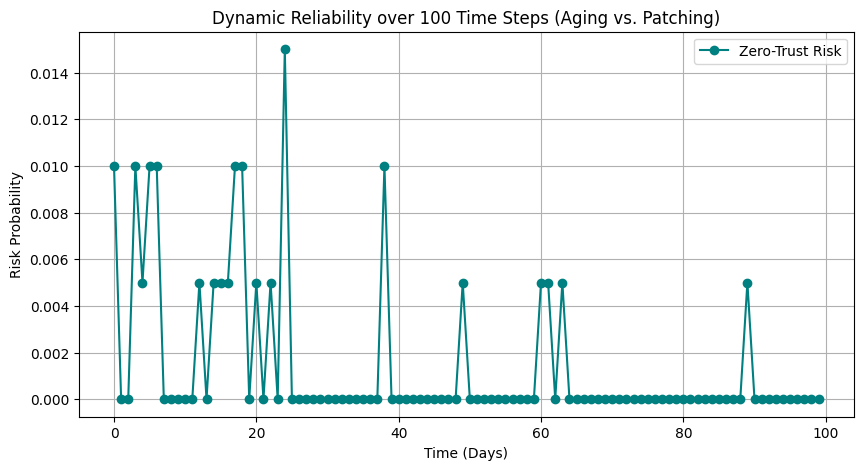

Analysis Complete. The graph shows the battle between new vulnerabilities and periodic patching.
In a Zero-Trust network, the risk stabilizes near zero after the hardening phase.


In [8]:
print("\n--- 6.2 Dynamic Reliability Analysis (100 Steps) ---")

time_steps = 100
risks_over_time = []
dynamic_G = zt_G.copy() # Start with ZT model

for t in range(time_steps):
    # 1. Aging: Vulnerabilities slightly increase every day
    for u, v in dynamic_G.edges():
        dynamic_G[u][v]['asr'] = min(0.9, dynamic_G[u][v]['asr'] + 0.005)

    # 2. Patching: Every 5 days, we patch aggressively
    if t % 5 == 0:
        for u, v in dynamic_G.edges():
            dynamic_G[u][v]['asr'] = max(0.1, dynamic_G[u][v]['asr'] - 0.04)

    # 3. Measure Risk
    current_risk = monte_carlo_simulation(dynamic_G, "Web_Gateway", "User_DB", iterations=200)
    risks_over_time.append(current_risk)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(range(time_steps), risks_over_time, marker='o', linestyle='-', color='teal', label='Zero-Trust Risk')
plt.title("Dynamic Reliability over 100 Time Steps (Aging vs. Patching)")
plt.xlabel("Time (Days)")
plt.ylabel("Risk Probability")
plt.grid(True)
plt.legend()
plt.show()

print("Analysis Complete. The graph shows the battle between new vulnerabilities and periodic patching.")
print("In a Zero-Trust network, the risk stabilizes near zero after the hardening phase.")
